<a href="https://colab.research.google.com/github/CatalinaOrtegha/IA-aumentada-previsi-n-de-atrasos-de-vuelos/blob/main/Ejercicio_optimizacion_aeroportuaria.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Entendiendo el conjunto de datos

In [49]:
import pandas as pd

In [50]:
url='https://raw.githubusercontent.com/CatalinaOrtegha/IA-aumentada-previsi-n-de-atrasos-de-vuelos/refs/heads/main/flights.csv'

datos=pd.read_csv(url)
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71175 entries, 0 to 71174
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   flight_id       71175 non-null  int64  
 1   airline         71175 non-null  object 
 2   aircraft_type   71175 non-null  object 
 3   schengen        71175 non-null  object 
 4   origin          71175 non-null  object 
 5   arrival_time    71175 non-null  float64
 6   departure_time  71175 non-null  float64
 7   day             71175 non-null  int64  
 8   year            71175 non-null  int64  
 9   is_holiday      71175 non-null  bool   
 10  delay           71175 non-null  float64
dtypes: bool(1), float64(3), int64(3), object(4)
memory usage: 5.5+ MB


In [51]:
datos.head()

,flight_id,airline,aircraft_type,schengen,origin,arrival_time,departure_time,day,year,is_holiday,delay
0,26,MM,Airbus A320,non-schengen,TCY,8.885071,10.885071,0,2010,False,70.205981
1,10,YE,Airbus A320,non-schengen,TCY,8.939996,11.939996,0,2010,False,38.484609
2,3,BZ,Embraer E175,schengen,TZF,18.635384,22.635384,0,2010,False,2.388305
3,28,BZ,Airbus A330,non-schengen,EMM,15.967963,17.967963,0,2010,False,19.138491
4,15,BZ,Airbus A330,non-schengen,FJB,16.571894,19.571894,0,2010,False,15.016271


In [52]:
datos.describe()

,flight_id,arrival_time,departure_time,day,year,delay
count,71175.000000,71175.000000,71175.000000,71175.000000,71175.000000,71175.000000
mean,15.465135,13.283159,16.480222,182.000000,2016.000000,12.548378
std,8.649646,4.023380,4.143705,105.366769,3.741684,23.125349
min,1.000000,7.065594,10.065594,0.000000,2010.000000,-41.028033
25%,8.000000,8.939996,12.668655,91.000000,2013.000000,-4.412876
50%,15.000000,14.258911,16.376052,182.000000,2016.000000,9.740454
75%,23.000000,16.909690,20.041281,273.000000,2019.000000,27.650853
max,30.000000,19.341235,23.341235,364.000000,2022.000000,125.632352


In [53]:
datos.describe(include='O')

,airline,aircraft_type,schengen,origin
count,71175,71175,71175,71175
unique,3,6,2,10
top,BZ,Airbus A320,schengen,TZF
freq,47598,30778,42569,14162


# Análisis gráfico del conjunto de datos

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt


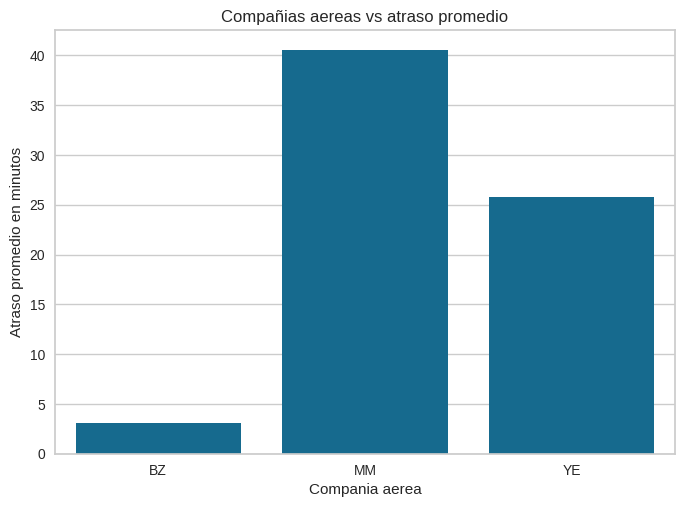

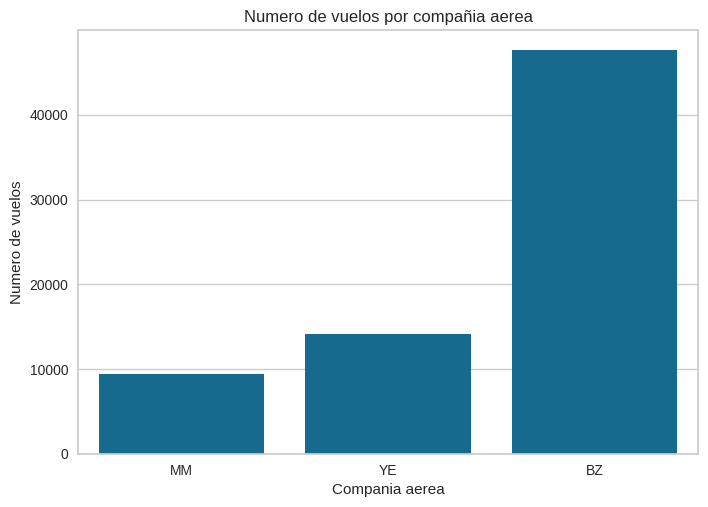

In [55]:
avg_delay = datos.groupby('airline')['delay'].mean().reset_index()
sns.barplot(x='airline', y='delay', data=avg_delay)
plt.title('Compañias aereas vs atraso promedio')
plt.xlabel('Compania aerea')
plt.ylabel('Atraso promedio en minutos')
plt.show()

sns.countplot(data=datos, x='airline')
plt.title('Numero de vuelos por compañia aerea')
plt.xlabel('Compania aerea')
plt.ylabel('Numero de vuelos')
plt.show()

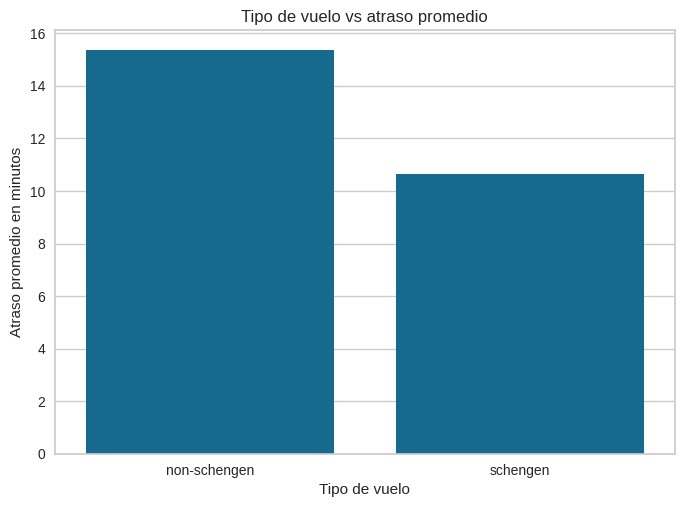

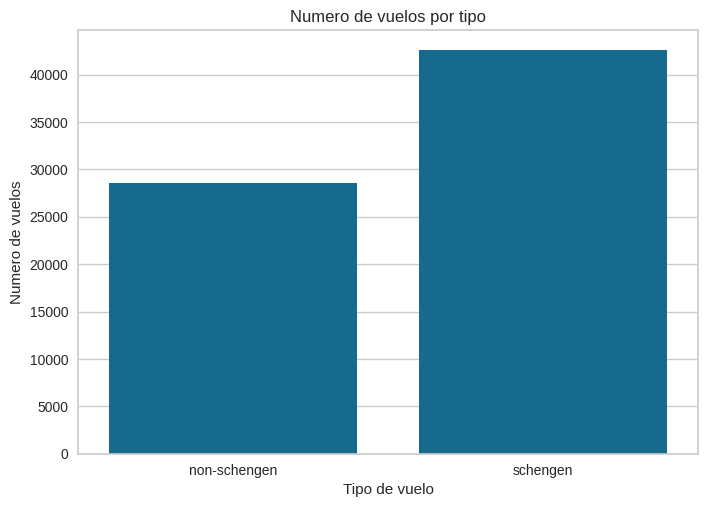

In [56]:
avg_delay = datos.groupby('schengen')['delay'].mean().reset_index()
sns.barplot(x='schengen', y='delay', data=avg_delay)
plt.title('Tipo de vuelo vs atraso promedio')
plt.xlabel('Tipo de vuelo')
plt.ylabel('Atraso promedio en minutos')
plt.show()

sns.countplot(data=datos, x='schengen')
plt.title('Numero de vuelos por tipo')
plt.xlabel('Tipo de vuelo')
plt.ylabel('Numero de vuelos')
plt.show()

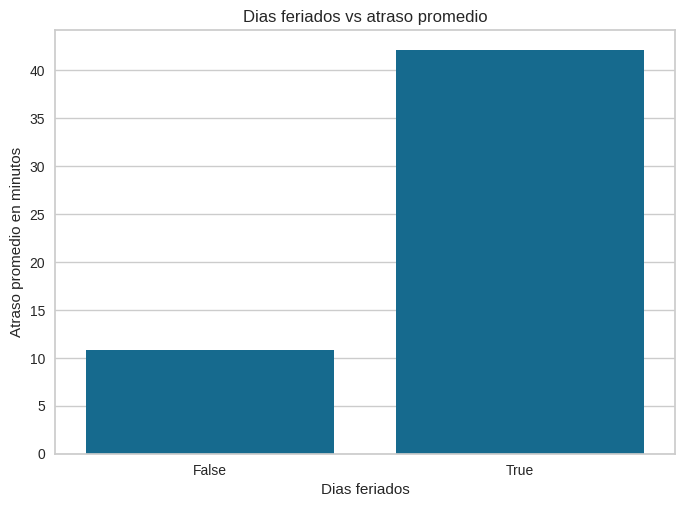

In [57]:
avg_delay = datos.groupby('is_holiday')['delay'].mean().reset_index()
sns.barplot(x='is_holiday', y='delay', data=avg_delay)
plt.title('Dias feriados vs atraso promedio')
plt.xlabel('Dias feriados')
plt.ylabel('Atraso promedio en minutos')
plt.show()

In [58]:
datos['aircraft_type'].value_counts().index

Index(['Airbus A320', 'Airbus A330', 'Boeing 787', 'Embraer E175',
       'Boeing 737', 'Boeing 777'],
      dtype='object', name='aircraft_type')

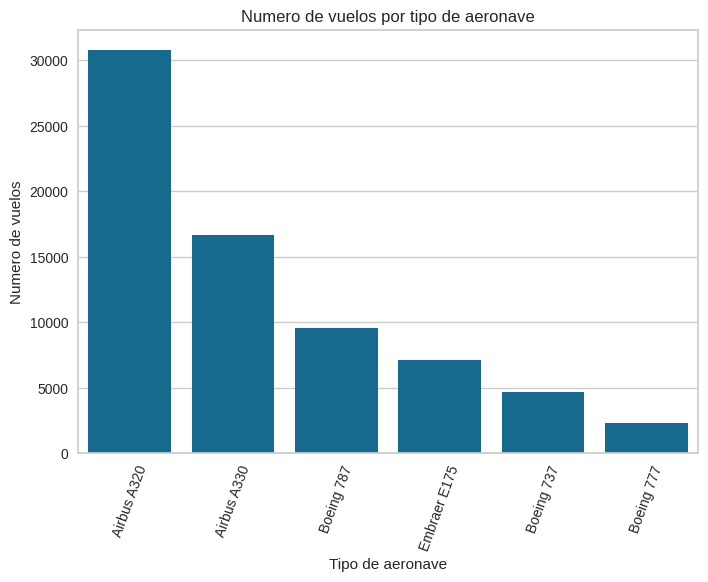

In [59]:
order = datos['aircraft_type'].value_counts().index

sns.countplot(data=datos, x='aircraft_type', order=order)
plt.title('Numero de vuelos por tipo de aeronave')
plt.xticks(rotation=70)
plt.xlabel('Tipo de aeronave')
plt.ylabel('Numero de vuelos')
plt.show()

# Analizando la distribución de los datos

In [60]:
#Freedman Diaconis (Tamaño de los bins)

In [61]:
import numpy as np

def ancho_bin (df,columna):
  q75,q25 = np.percentile(df[columna],[75,25])
  iqr = q75 - q25
  ancho = 2 * iqr * np.power(len(df[columna]),-1/3)
  return ancho


<Axes: xlabel='arrival_time', ylabel='Count'>

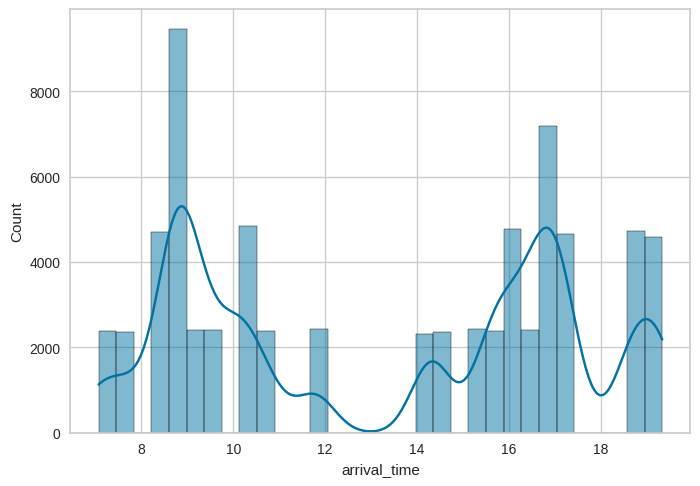

In [62]:
binwidth = ancho_bin(datos,'arrival_time')
sns.histplot(data=datos, x='arrival_time', kde=True, binwidth=binwidth)


<Axes: xlabel='departure_time', ylabel='Count'>

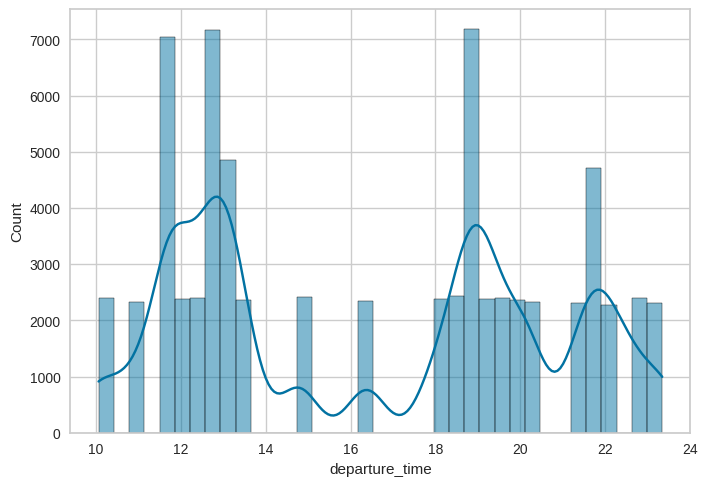

In [63]:
binwidth = ancho_bin(datos,'departure_time')
sns.histplot(data=datos, x='departure_time', kde=True, binwidth=binwidth)

In [64]:
atraso_promedio = datos['delay'].mean()
atraso_mediana = datos['delay'].median()

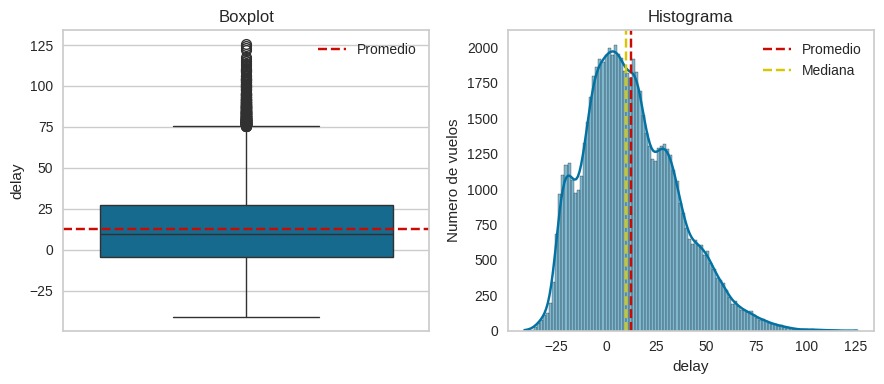

In [65]:
fig, ax = plt.subplots(1,2, figsize=(9, 4))
sns.boxplot(data=datos, y='delay', ax=ax[0])
ax[0].set_title('Boxplot')
ax[0].axhline(y=atraso_promedio, color='r', linestyle='--', label = 'Promedio')
ax[0].legend()

binwidth= ancho_bin(datos,'delay')
sns.histplot(data=datos, x='delay', ax=ax[1], kde=True, binwidth=binwidth)
plt.ylabel('Numero de vuelos')
plt.grid(False)
ax[1].set_title('Histograma')
ax[1].axvline(x=atraso_promedio, color='r', linestyle='--', label = 'Promedio')
ax[1].axvline(x=atraso_mediana, color='y', linestyle='--', label = 'Mediana')
ax[1].legend()

plt.tight_layout()
plt.show()


#Creando nuevas columnas

In [66]:
datos.columns


Index(['flight_id', 'airline', 'aircraft_type', 'schengen', 'origin',
       'arrival_time', 'departure_time', 'day', 'year', 'is_holiday', 'delay'],
      dtype='object')

In [67]:
datos['date'] = datos['year'].astype(str) + '-' + (datos['day']+1).astype(str)
datos['date'] = pd.to_datetime(datos['date'], format='%Y-%j')
datos.tail(2)

,flight_id,airline,aircraft_type,schengen,origin,arrival_time,departure_time,day,year,is_holiday,delay,date
71173,5,BZ,Airbus A320,schengen,ZQO,9.344097,12.344097,364,2022,True,56.758844,2022-12-31
71174,29,BZ,Boeing 737,schengen,ZQO,8.591208,11.591208,364,2022,True,41.401648,2022-12-31


In [68]:
datos['is_weekend'] = datos['date'].dt.weekday.isin([5,6])
datos['day_name'] = datos['date'].dt.day_name()
datos.head()

,flight_id,airline,aircraft_type,schengen,origin,arrival_time,departure_time,day,year,is_holiday,delay,date,is_weekend,day_name
0,26,MM,Airbus A320,non-schengen,TCY,8.885071,10.885071,0,2010,False,70.205981,2010-01-01,False,Friday
1,10,YE,Airbus A320,non-schengen,TCY,8.939996,11.939996,0,2010,False,38.484609,2010-01-01,False,Friday
2,3,BZ,Embraer E175,schengen,TZF,18.635384,22.635384,0,2010,False,2.388305,2010-01-01,False,Friday
3,28,BZ,Airbus A330,non-schengen,EMM,15.967963,17.967963,0,2010,False,19.138491,2010-01-01,False,Friday
4,15,BZ,Airbus A330,non-schengen,FJB,16.571894,19.571894,0,2010,False,15.016271,2010-01-01,False,Friday


# Feature Encoding

In [69]:
import warnings
warnings.filterwarnings('ignore')

In [70]:
datos['schengen'] = datos['schengen'].replace({'non-schengen':0,'schengen':1})
datos['is_holiday'] = datos['is_holiday'].replace({False:0,True:1})
datos['is_weekend'] = datos['is_weekend'].replace({False:0,True:1})
datos.sample(3)

,flight_id,airline,aircraft_type,schengen,origin,arrival_time,departure_time,day,year,is_holiday,delay,date,is_weekend,day_name
17816,17,BZ,Airbus A330,0,CNU,16.718722,21.718722,92,2013,0,-6.837993,2013-04-03,0,Wednesday
18381,25,BZ,Boeing 777,0,CSF,19.341235,23.341235,130,2013,0,10.887493,2013-05-11,1,Saturday
16981,29,BZ,Boeing 737,1,ZQO,8.591208,11.591208,37,2013,0,-0.370691,2013-02-07,0,Thursday


In [71]:
categoricas = ['airline','aircraft_type','origin','day_name']
datos_codificados = pd.get_dummies(data=datos, columns=categoricas, dtype=int)
datos_codificados.sample(5)

,flight_id,schengen,arrival_time,departure_time,day,year,is_holiday,delay,date,is_weekend,...,origin_TCY,origin_TZF,origin_ZQO,day_name_Friday,day_name_Monday,day_name_Saturday,day_name_Sunday,day_name_Thursday,day_name_Tuesday,day_name_Wednesday
29105,22,0,8.794147,11.794147,115,2015,0,3.138262,2015-04-26,1,...,0,0,0,0,0,0,1,0,0,0
38548,11,0,10.177197,13.177197,14,2017,0,15.976706,2017-01-15,1,...,0,0,0,0,0,0,1,0,0,0
40782,18,1,14.258911,20.258911,163,2017,0,4.701030,2017-06-13,0,...,0,1,0,0,0,0,0,0,1,0
25370,25,0,19.341235,23.341235,231,2014,0,27.926907,2014-08-20,0,...,0,0,0,0,0,0,0,0,0,1
12938,27,1,14.376052,16.376052,132,2012,0,18.658677,2012-05-12,1,...,0,0,0,0,0,1,0,0,0,0


#Limpiando los datos

In [72]:
datos_codificados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71175 entries, 0 to 71174
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   flight_id                   71175 non-null  int64         
 1   schengen                    71175 non-null  int64         
 2   arrival_time                71175 non-null  float64       
 3   departure_time              71175 non-null  float64       
 4   day                         71175 non-null  int64         
 5   year                        71175 non-null  int64         
 6   is_holiday                  71175 non-null  int64         
 7   delay                       71175 non-null  float64       
 8   date                        71175 non-null  datetime64[ns]
 9   is_weekend                  71175 non-null  int64         
 10  airline_BZ                  71175 non-null  int64         
 11  airline_MM                  71175 non-null  int64     

In [73]:
datos[['arrival_time','departure_time']].corr()

,arrival_time,departure_time
arrival_time,1.000000,0.973797
departure_time,0.973797,1.000000


In [74]:
df =  datos_codificados.drop(columns=['flight_id','departure_time','day','year','date'])
df.sample(10)

,schengen,arrival_time,is_holiday,delay,is_weekend,airline_BZ,airline_MM,airline_YE,aircraft_type_Airbus A320,aircraft_type_Airbus A330,...,origin_TCY,origin_TZF,origin_ZQO,day_name_Friday,day_name_Monday,day_name_Saturday,day_name_Sunday,day_name_Thursday,day_name_Tuesday,day_name_Wednesday
64549,1,7.708301,0,-13.954913,1,1,0,0,0,1,...,0,0,1,0,0,1,0,0,0,0
53103,1,19.196804,0,-2.632082,0,1,0,0,1,0,...,0,0,1,1,0,0,0,0,0,0
15524,1,11.781391,0,-23.689939,0,1,0,0,0,1,...,1,0,0,0,0,0,0,0,0,1
15583,1,7.065594,0,24.278845,1,1,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
32352,1,9.344097,0,7.541090,1,1,0,0,1,0,...,0,0,1,0,0,1,0,0,0,0
50463,1,8.564949,0,13.555685,0,0,1,0,0,0,...,0,1,0,0,0,0,0,1,0,0
38820,0,8.885071,0,27.998852,0,0,1,0,1,0,...,1,0,0,1,0,0,0,0,0,0
6480,0,8.885071,0,32.235088,0,0,1,0,1,0,...,1,0,0,0,0,0,0,0,0,1
52298,1,17.033688,0,9.130208,1,0,0,1,0,0,...,0,0,0,0,0,0,1,0,0,0
27839,1,19.196804,0,-9.950744,1,1,0,0,1,0,...,0,0,1,0,0,1,0,0,0,0


# Definiendo una baseline

In [75]:
#Punto de partida

In [76]:
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import train_test_split

In [77]:
X = df.drop(['delay'], axis=1)
y= df['delay']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
baseline=DummyRegressor()
baseline.fit(X_train, y_train)



DummyRegressor()

In [78]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

y_pred_dummy = baseline.predict(X_test)

def calcular_regresion(y_test, y_pred):
  rmse = mean_squared_error(y_test, y_pred)
  mae = mean_absolute_error(y_test, y_pred)
  r2 = r2_score(y_test, y_pred)
  metricas = {'rmse': round(rmse**(1/2),4),
              'mae':round(mae,4),
              'r2':round(r2,4)}
  return metricas


In [79]:
resultados_baseline = calcular_regresion(y_test, y_pred_dummy)
resultados_baseline

{'rmse': 23.1612, 'mae': 18.5646, 'r2': -0.0}

# Entrenando con bosques aleatorios

In [80]:
from sklearn.ensemble import RandomForestRegressor

In [81]:
modelo = RandomForestRegressor(max_depth=5, random_state=42)
modelo.fit(X_train, y_train)

ypred= modelo.predict(X_test)
resultados_rf= calcular_regresion(y_test, ypred)
resultados_rf

{'rmse': 13.7479, 'mae': 11.0262, 'r2': 0.6477}

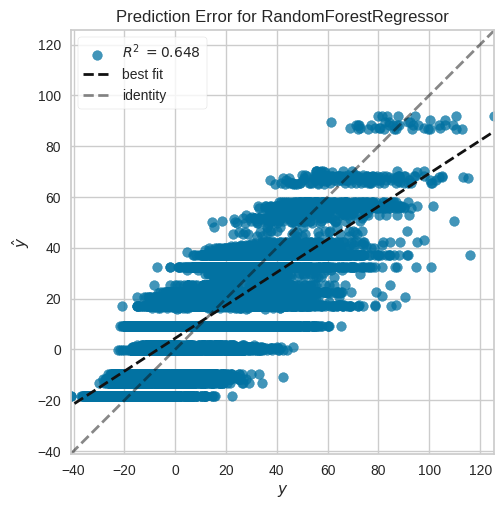

In [82]:
from yellowbrick.regressor import prediction_error

visualizer = prediction_error(modelo,X_train,y_train,X_test,y_test);

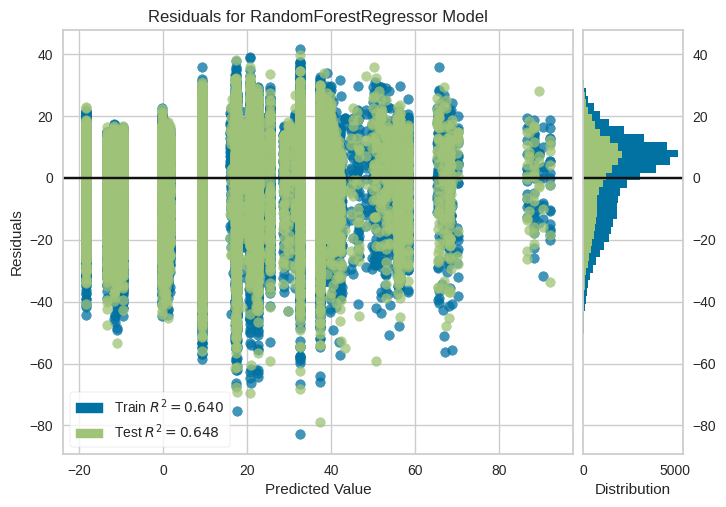

In [83]:
from yellowbrick.regressor import residuals_plot

viz = residuals_plot(modelo,X_train,y_train,X_test,y_test);

# Realizando cross validation

In [84]:
from sklearn.model_selection import KFold, cross_validate

scoring= {
    'rmse':'neg_root_mean_squared_error',
    'mae':'neg_mean_absolute_error',
    'r2':'r2'
}

cv= KFold(n_splits=5, shuffle=True, random_state=42)
cv_results= cross_validate(modelo, X_train, y_train, scoring=scoring, cv=cv)
cv_results

{'fit_time': array([3.0563097 , 4.17762208, 3.16481805, 7.47085285, 3.78307986]),
 'score_time': array([0.06736326, 0.05797482, 0.05547404, 0.07434535, 0.05438733]),
 'test_rmse': array([-13.76989748, -13.86928373, -13.96807668, -13.85347402,
        -13.98953528]),
 'test_mae': array([-11.03252135, -11.13534968, -11.2094657 , -11.14503717,
        -11.25775565]),
 'test_r2': array([0.64559466, 0.63745663, 0.63523823, 0.64089302, 0.63441267])}

# Feature importances

In [85]:
len(df.columns)

31

In [86]:
importances = modelo.feature_importances_

In [87]:
feature_importances= pd.DataFrame({'Features': X.columns, 'Importances': (importances*100).round(2)}).sort_values(by='Importances', ascending=False)
feature_importances

,Features,Importances
4,airline_BZ,53.03
2,is_holiday,14.59
7,aircraft_type_Airbus A320,10.07
8,aircraft_type_Airbus A330,5.76
12,aircraft_type_Embraer E175,4.59
1,arrival_time,3.60
11,aircraft_type_Boeing 787,2.64
20,origin_TCY,2.09
15,origin_CSF,1.60
19,origin_PUA,1.03


In [88]:
resultados= pd.DataFrame(index=['rmse','mae','r2'])
model_features = RandomForestRegressor(max_depth=5, random_state=42)
ct_features = [i if i !=0 else 1 for i in range(0,35,5)]


for i in ct_features:
  selected_features = feature_importances['Features'].values[:i]
  X_train_sel = X_train[selected_features]
  X_test_sel = X_test[selected_features]
  model_features.fit(X_train_sel, y_train)
  y_pred = model_features.predict(X_test_sel)
  metricas = calcular_regresion(y_test, y_pred)
  resultados[i] = list(metricas.values())

resultados

,1,5,10,15,20,25,30
rmse,18.8331,15.1564,13.7587,13.7497,13.7498,13.7477,13.7479
mae,14.9620,12.0605,11.0422,11.0285,11.0280,11.0261,11.0262
r2,0.3388,0.5718,0.6471,0.6476,0.6476,0.6477,0.6477


In [89]:
resultados= pd.DataFrame(index=['rmse','mae','r2'])
model_features = RandomForestRegressor(max_depth=5, random_state=42)
ct_features = range(10,16)


for i in ct_features:
  selected_features = feature_importances['Features'].values[:i]
  X_train_sel = X_train[selected_features]
  X_test_sel = X_test[selected_features]
  model_features.fit(X_train_sel, y_train)
  y_pred = model_features.predict(X_test_sel)
  metricas = calcular_regresion(y_test, y_pred)
  resultados[i] = list(metricas.values())

resultados

,10,11,12,13,14,15
rmse,13.7587,13.7564,13.7526,13.7526,13.7497,13.7497
mae,11.0422,11.0425,11.0312,11.0314,11.0285,11.0285
r2,0.6471,0.6472,0.6474,0.6474,0.6476,0.6476


In [90]:
selected_features = feature_importances['Features'].values[:13]
X_selected_features = X[selected_features]
X_selected_features

,airline_BZ,is_holiday,aircraft_type_Airbus A320,aircraft_type_Airbus A330,aircraft_type_Embraer E175,arrival_time,aircraft_type_Boeing 787,origin_TCY,origin_CSF,origin_PUA,origin_TZF,day_name_Friday,origin_MWL
0,0,0,1,0,0,8.885071,0,1,0,0,0,1,0
1,0,0,1,0,0,8.939996,0,1,0,0,0,1,0
2,1,0,0,0,1,18.635384,0,0,0,0,1,1,0
3,1,0,0,1,0,15.967963,0,0,0,0,0,1,0
4,1,0,0,1,0,16.571894,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
71170,1,1,0,0,1,18.635384,0,0,0,0,1,0,0
71171,1,1,0,1,0,16.718722,0,0,0,0,0,0,0
71172,0,1,0,0,0,8.564949,1,0,0,0,1,0,0
71173,1,1,1,0,0,9.344097,0,0,0,0,0,0,0


In [91]:
X_train,X_test,y_train,y_test = train_test_split(X_selected_features,y,random_state=42)

In [96]:
param_grid= {
    'max_depth':[5,10,15],
    'min_samples_split':[2,4,6],
    'min_samples_leaf':[1,2,3],
    'n_estimators':[100,150,200]
}


In [111]:
from sklearn.model_selection import RandomizedSearchCV

model_random = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    param_distributions=param_grid,
    n_iter=10,  # solo prueba 10 combinaciones
    cv=3,
    scoring='r2',
    n_jobs=-1,
    random_state=42
)

model_random.fit(X_train, y_train)

RandomizedSearchCV(cv=3, estimator=RandomForestRegressor(random_state=42),
                   n_jobs=-1,
                   param_distributions={'max_depth': [5, 10, 15],
                                        'min_samples_leaf': [1, 2, 3],
                                        'min_samples_split': [2, 4, 6],
                                        'n_estimators': [100, 130, 150]},
                   random_state=42, scoring='r2')

In [116]:
model_random.best_params_

{'n_estimators': 100,
 'min_samples_split': 4,
 'min_samples_leaf': 1,
 'max_depth': 10}

In [113]:
model_random.best_score_

np.float64(0.6656280159198388)

In [115]:
from sklearn.metrics import r2_score

y_pred_random = model_random.best_estimator_.predict(X_test)

metricas_model_randim = calcular_regresion(y_test, y_pred_random)
metricas_model_randim

{'rmse': 13.2302, 'mae': 10.6288, 'r2': 0.6755}

In [117]:
resultados['model_random'] = list(metricas_model_randim.values())
resultados

,10,11,12,13,14,15,model_random
rmse,13.7587,13.7564,13.7526,13.7526,13.7497,13.7497,13.2302
mae,11.0422,11.0425,11.0312,11.0314,11.0285,11.0285,10.6288
r2,0.6471,0.6472,0.6474,0.6474,0.6476,0.6476,0.6755
